In [1]:
import sys
sys.path.append("..")
import numpy as np
import emcee
import matplotlib.pyplot as plt
import matplotlib as mpl
from getdist import plots, MCSamples
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Computer Modern Roman"]

In [2]:
%load_ext autoreload
%autoreload 2
import strings as cs

In [3]:
ACT = cs.ACTDR6
PLANCK = cs.PLANCK18

In [4]:
Lmin=0
Lmax=3000

In [5]:
maskact = (ACT.L > Lmin) & (ACT.L < Lmax)
maskplanck = (PLANCK.L > Lmin) & (PLANCK.L < Lmax)

In [6]:
Gmu_ref = 8.0e-4
P_fixed = 1.0

CL_ref_al = cs.compute_cl(Gmu_ref, P_fixed, ell_arr=ACT.L[maskact])
CL_ref_pl = cs.compute_cl(Gmu_ref, P_fixed, ell_arr=PLANCK.L[maskplanck])

In [7]:
def model_cl_ACT(Gmu):
    return CL_ref_al * (Gmu / Gmu_ref)**2
def model_cl_PLANCK(Gmu):
    return CL_ref_pl * (Gmu / Gmu_ref)**2

In [8]:
def log_likelihood_ACT(theta):
    Gmu = theta[0]
    if Gmu <= 0:
        return -np.inf
    model = model_cl_ACT(Gmu)
    chi2 = np.sum(((ACT.CL[maskact] - model) / ACT.ER[maskact])**2)
    return -0.5 * chi2
def log_likelihood_PLANCK(theta):
    Gmu = theta[0]
    if Gmu <= 0:
        return -np.inf
    model = model_cl_PLANCK(Gmu)
    chi2 = np.sum(((PLANCK.CL[maskplanck] - model) / PLANCK.ER[maskplanck])**2)
    return -0.5 * chi2

def log_likelihood_JOINT(theta):
    Gmu = theta[0]
    if Gmu <= 0:
        return -np.inf
    model_ACT = model_cl_ACT(Gmu)
    model_PLANCK = model_cl_PLANCK(Gmu)
    chi2_ACT = np.sum(((ACT.CL[maskact] - model_ACT) / ACT.ER[maskact])**2)
    chi2_PLANCK = np.sum(((PLANCK.CL[maskplanck] - model_PLANCK) / PLANCK.ER[maskplanck])**2)
    return -0.5 * (chi2_ACT + chi2_PLANCK)

In [9]:
def log_prior(theta):
    Gmu = theta[0]
    if 0 < Gmu < 1e-2:
        return 0.0
    return -np.inf

In [10]:
def log_probability_ACT(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_ACT(theta)

def log_probability_PLANCK(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_PLANCK(theta)

def log_probability_JOINT(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_JOINT(theta)

In [11]:
nwalkers = 20
ndim = 1
initial = Gmu_ref * (1 + 0.1 * np.random.randn(nwalkers, ndim))


In [12]:
sampler_ACT = emcee.EnsembleSampler(nwalkers, ndim, log_probability_ACT)
s_ACT = sampler_ACT.run_mcmc(initial, 10000, progress=True)

100%|██████████| 10000/10000 [00:02<00:00, 3847.03it/s]


In [13]:
sampler_PLANCK = emcee.EnsembleSampler(nwalkers, ndim, log_probability_PLANCK)
s_planck = sampler_PLANCK.run_mcmc(initial, 10000, progress=True)

100%|██████████| 10000/10000 [00:02<00:00, 3552.84it/s]


In [14]:
sampler_JOINT = emcee.EnsembleSampler(nwalkers, ndim, log_probability_JOINT)
s_joint = sampler_JOINT.run_mcmc(initial, 10000, progress=True)

100%|██████████| 10000/10000 [00:03<00:00, 2769.39it/s]


In [15]:
samples_act = sampler_ACT.get_chain(discard=500, thin=10, flat=True)
samples_planck = sampler_PLANCK.get_chain(discard=500, thin=10, flat=True)
samples_joint = sampler_JOINT.get_chain(discard=500, thin=10, flat=True)
Gmu_samples_act = samples_act[:, 0]
Gmu_samples_planck = samples_planck[:, 0]
Gmu_samples_joint = samples_joint[:, 0]
upper_2sigma_act = np.percentile(Gmu_samples_act, 95)
upper_2sigma_planck = np.percentile(Gmu_samples_planck, 95)
upper_2sigma_joint = np.percentile(Gmu_samples_joint, 95)

In [16]:
gd_samples_act = MCSamples(
    samples=Gmu_samples_act,
    names=["gmu"],
    labels=[r"G\mu"],settings={"mult_bias_correction_order": 1}, ranges={"gmu": [0, None]}
)
gd_samples_planck = MCSamples(
    samples=Gmu_samples_planck,
    names=["gmu"], labels=[r"G\mu"],settings={"mult_bias_correction_order": 1}, ranges={"gmu": [0, None]}
)
gd_samples_joint = MCSamples(
    samples=Gmu_samples_joint,
    names=["gmu"], labels=[r"G\mu"],settings={"mult_bias_correction_order": 1}, ranges={"gmu": [0, None]}
)


Removed no burn in
Removed no burn in
Removed no burn in


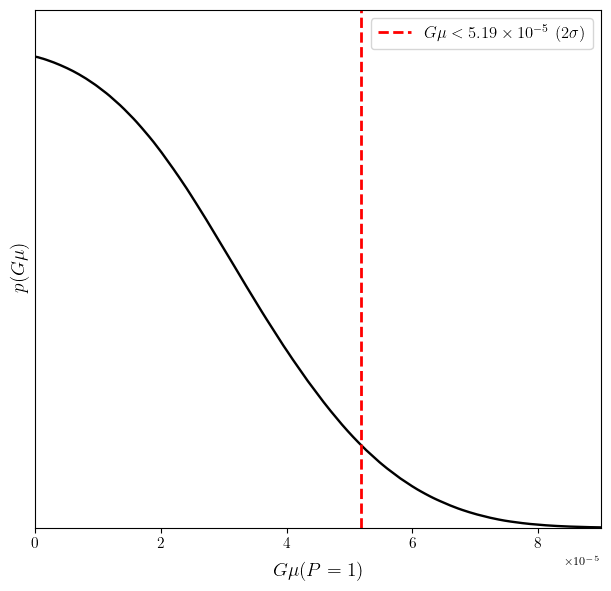

In [ ]:
g = plots.get_single_plotter(width_inch=6,ratio=1)
g.plot_1d(gd_samples_act, "gmu")
ax = plt.gca()
mantissa, exp = f"{upper_2sigma_act:.2e}".split("e")
constraint_latex = rf"$G\mu < {mantissa}\times 10^{{{int(exp)}}}$ (2$\sigma$)"
ax.axvline(upper_2sigma_act, color="red", linestyle="--", linewidth=2,
           label=constraint_latex)
ax.set_xlabel(r"$G\mu (P=1)$", fontsize=14)
ax.set_ylabel(r"$p(G\mu)$", fontsize=14)
ax.legend(loc="upper right", fontsize=12)
#ax.set_title("ACT DR6 Constraint on $G\mu$", fontsize=16)
plt.savefig("plots/Gmu_Constraint_Plot.pdf", dpi=300, bbox_inches='tight')

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/fk/bw41mft54xv7g50r77fysgwh0000gn/T/ipykernel_28196/1375292427.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Planck 2018 Constraint on $G\mu$", fontsize=16)


Text(0.5, 1.0, 'Planck 2018 Constraint on $G\\mu$')

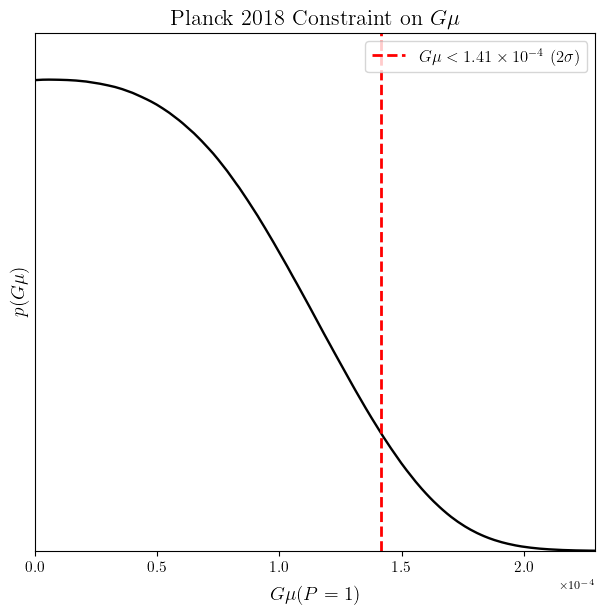

In [21]:

g = plots.get_single_plotter(width_inch=6,ratio=1)
g.plot_1d(gd_samples_planck, "gmu")
ax = plt.gca()
mantissa, exp = f"{upper_2sigma_planck:.2e}".split("e")
constraint_latex = rf"$G\mu < {mantissa}\times 10^{{{int(exp)}}}$ (2$\sigma$)"
ax.axvline(upper_2sigma_planck, color="red", linestyle="--", linewidth=2,
           label=constraint_latex)
ax.set_xlabel(r"$G\mu (P=1)$", fontsize=14)
ax.set_ylabel(r"$p(G\mu)$", fontsize=14)
ax.legend(loc="upper right", fontsize=12)
ax.set_title("Planck 2018 Constraint on $G\mu$", fontsize=16)


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/fk/bw41mft54xv7g50r77fysgwh0000gn/T/ipykernel_28196/2751519487.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("Joint ACT DR6 + Planck 2018 Constraint on $G\mu$", fontsize=16)


Text(0.5, 1.0, 'Joint ACT DR6 + Planck 2018 Constraint on $G\\mu$')

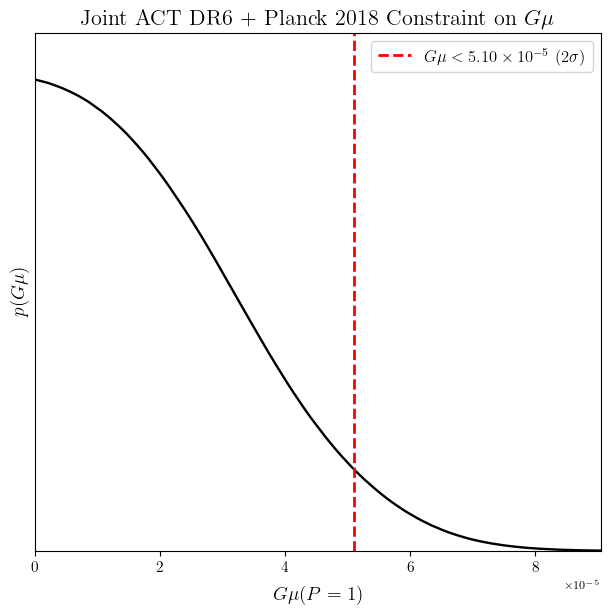

In [22]:

g = plots.get_single_plotter(width_inch=6,ratio=1)
g.plot_1d(gd_samples_joint, "gmu")
ax = plt.gca()
mantissa, exp = f"{upper_2sigma_joint:.2e}".split("e")
constraint_latex = rf"$G\mu < {mantissa}\times 10^{{{int(exp)}}}$ (2$\sigma$)"
ax.axvline(upper_2sigma_joint, color="red", linestyle="--", linewidth=2,
           label=constraint_latex)
ax.set_xlabel(r"$G\mu (P=1)$", fontsize=14)
ax.set_ylabel(r"$p(G\mu)$", fontsize=14)
ax.legend(loc="upper right", fontsize=12)
ax.set_title("Joint ACT DR6 + Planck 2018 Constraint on $G\mu$", fontsize=16) 